In [23]:
%load_ext autoreload
%autoreload 2
from CustomModules.proteines_extract_3d import *
from utils import *
from CustomModules.architectures import *
from CustomModules.normalizing_flow import normalizing_flow

from sklearn.model_selection import train_test_split

import pickle
import os
from jax.example_libraries import stax
from numpyro import optim
import jax
import jax.numpy as jnp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Jax psuedo random keys


In [2]:

# For reproducibility, we define a deterministic hashing function for our random keys
# Each unique string will correspond to a unique random independent key, but the same string will always yield the same key.
# Here I make sure to start at a different key from Toy Data experiments
key_for = make_key_for(jax.random.key(3))

E0604 13:42:26.336571    1979 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0604 13:42:26.351492    1707 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


# Data

In [3]:
ensemble_backbone = load_backbone_npy("proteines/2eq8_ensemble_theseus_backbone.npy")
X = ensemble_backbone.reshape(ensemble_backbone.shape[0], -1)
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
train_loader = [X_train]
test_loader = [X_test]
train_size = X_train.shape[0]
test_size = X_test.shape[0]

In [4]:
ensemble_backbone[0, :, 0, :].shape

(39, 3)

In [5]:
plot_protein(ensemble_backbone[3], "First Atom")

# Define Model Architectures

## Networks

In [6]:

def encoder(hidden_dim, z_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.FanOut(2),
        stax.parallel(
            stax.Dense(z_dim, W_init=stax.randn()),
            stax.serial(stax.Dense(z_dim, W_init=stax.randn()), stax.Exp),
        ),
    )


def decoder(hidden_dim, out_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(out_dim, W_init=stax.randn()),
    )

def f_shared(hidden_dim, f_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(f_dim, W_init=stax.randn()),
    )

def g(z_dim, variance_floor=0.1):
    SafeSoftplus = stax.elementwise(lambda x: jnp.clip(stax.softplus(x-3.0), min=0.0, max=20.0) + variance_floor)
    return stax.serial(
        stax.FanOut(2),
        stax.parallel(
            stax.serial(stax.Dense(z_dim), stax.elementwise(lambda x: jnp.clip(x, -10.0, 10.0))),
            stax.serial(stax.Dense(z_dim), SafeSoftplus),
        )
    )

def h(hidden_dim, h_dim):
    return stax.serial(
        stax.Dense(hidden_dim),
        stax.LeakyRelu,
        stax.Dense(h_dim),
    )




## Hyper parameters

In [7]:

out_dim = X_train.shape[1]
hidden_dim =128
z_dim = 50
m_dim = 5


lr=5e-4

def lr_scheduler(lr_start=5e-3, decay_rate=0.9, decay_steps=300, floor=1e-5):
    def schedule(step):
        return lr_start * (decay_rate ** (step // decay_steps)) + floor
    return schedule

encoder_args = {"hidden_dim": hidden_dim, "z_dim": z_dim}
decoder_args = {"hidden_dim": hidden_dim, "out_dim": out_dim}
f_args = {"hidden_dim": z_dim, "f_dim": z_dim}
g_args = {"z_dim": z_dim, "variance_floor": 0.05}
h_args = {"hidden_dim": z_dim, "h_dim": z_dim}
flow_args = {"input_dim": m_dim, "hidden_dims": [m_dim], "steps": 0, "inv": True} # steps: 0 means flow is deactivated
hierarchical_layers = 2 # for the hierarchical model
num_stein_particles = 5
num_elbo_particles = 10
bandwidth_scaler=0.03


num_epochs = 10000
annealing_epochs = 2000

steps = num_epochs
lr_scheduler_fn = lr_scheduler(lr, decay_rate=0.9, decay_steps=steps/30, floor=1e-5)
adam = optim.ClippedAdam(lr_scheduler_fn, clip_norm=10) # clipping for stability

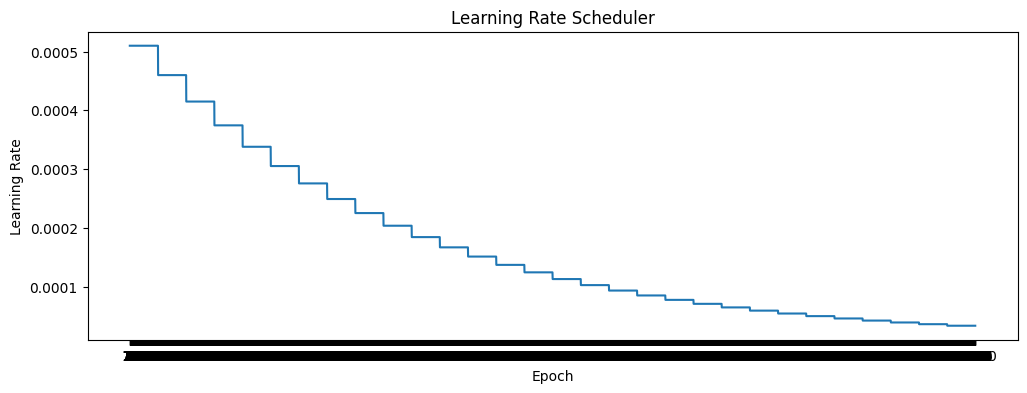

In [8]:
lrs = [lr_scheduler_fn(step) for step in range(int(steps))]
plt.figure(figsize=(12, 4))
plt.plot(lrs)

plt.title("Learning Rate Scheduler")

plt.xticks(np.linspace(0, steps, num_epochs+1), [f"{i}" for i in range(num_epochs+1)])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.show()


## Define models


In [9]:
ordinary_vae = BaseVAE(encoder, encoder_args, decoder, decoder_args, z_dim, normal_scale=0.5)
stein_global_vae = SteinGlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim, normal_scale=0.5)
stein_hierarchical_vae = SteinHierarchicalVAE(decoder, decoder_args, f_shared, f_args, h, h_args, g, g_args, g, g_args, hierarchical_layers, z_dim, m_dim, normalizing_flow, flow_args, normal_scale=0.5)


# Training

In [10]:
# Checkpoint names:
checkpoints_dir = "checkpoints_protein_data"
if not os.path.exists(checkpoints_dir):
    os.makedirs(checkpoints_dir)
checkpoint_ordinary = f"{checkpoints_dir}/protein_ordinary_vae_epochs={num_epochs}.pkl"
checkpoint_stein_global = f"{checkpoints_dir}/protein_stein_global_vae_epochs={num_epochs}_stein_particles={num_stein_particles}.pkl"
checkpoint_stein_hierarchical = f"{checkpoints_dir}/protein_stein_hierarchical_vae_epochs={num_epochs}_stein_particles={num_stein_particles}.pkl"



If checkpoint already exists, then just load it, otherwise train. This ensures no wasted time

In [11]:
if os.path.exists(checkpoint_ordinary):
    with open(checkpoint_ordinary, "rb") as f:
        ordinary_vae = pickle.load(f)
    print("Loaded Ordinary VAE from checkpoint.")
else:
    ordinary_vae.train(train_loader, train_size, adam, num_epochs,  key_for("ordinary_vae_training"), annealing_epochs=annealing_epochs)
    with open(checkpoint_ordinary, "wb") as f:
        pickle.dump(ordinary_vae, f)
    print("Trained and saved Ordinary VAE.")

Loaded Ordinary VAE from checkpoint.


In [12]:
if os.path.exists(checkpoint_stein_global):
    with open(checkpoint_stein_global, "rb") as f:
        stein_global_vae, stein_global_vae_norms = pickle.load(f)
    print("Loaded Stein Global VAE from checkpoint.")
else:
    stein_global_vae_norms = stein_global_vae.train(train_loader, train_size, adam, num_epochs, key_for("stein_global_vae_training3"), num_stein_particles, 
                                                    annealing_epochs=annealing_epochs, num_elbo_particles=num_elbo_particles, bandwidth_scaler = bandwidth_scaler)
    with open(checkpoint_stein_global, "wb") as f:
        pickle.dump((stein_global_vae, stein_global_vae_norms), f)
    print("Trained and saved Stein Global VAE.")

Loaded Stein Global VAE from checkpoint.


In [13]:
if os.path.exists(checkpoint_stein_hierarchical):
    with open(checkpoint_stein_hierarchical, "rb") as f:
        stein_hierarchical_vae, stein_hierarchical_vae_norms = pickle.load(f)
    print("Loaded Stein Hierarchical VAE from checkpoint.")
else:
    stein_hierarchical_vae_norms = stein_hierarchical_vae.train(train_loader, train_size, adam, num_epochs, key_for("stein_hierarchical_vae_training"), 
                                                                num_stein_particles, num_elbo_particles=num_elbo_particles,
                                                                annealing_epochs=annealing_epochs, 
                                                                annealed_sites=[f"z{i}" for i in range(hierarchical_layers)],
                                                                bandwidth_scaler = bandwidth_scaler)
    with open(checkpoint_stein_hierarchical, "wb") as f:
        pickle.dump((stein_hierarchical_vae, stein_hierarchical_vae_norms), f)
    print("Trained and saved Stein Hierarchical VAE.")


Loaded Stein Hierarchical VAE from checkpoint.


# Results

In [14]:
# reconstruction for baseVAE:
encoded_ordinary = ordinary_vae.encode_batch(X_test, key_for("ordinary_vae_encoding"))
reconstructed_ordinary = np.array(ordinary_vae.decode_latent(encoded_ordinary, key_for("ordinary_vae_decoding"))["x"])

# reconstruction for global:
encoded_stein_global = stein_global_vae.encode_batch(X_test, key_for("stein_global_vae_encoding"))
reconstructed_stein_global = np.array(stein_global_vae.decode_latent(encoded_stein_global, key_for("stein_global_vae_decoding"))["x"])

# reconstruction for hierarchical:
encoded_stein_hierarchical = stein_hierarchical_vae.encode_batch(X_test, key_for("stein_hierarchical_vae_encoding"))
reconstructed_stein_hierarchical = np.array(stein_hierarchical_vae.decode_latent(encoded_stein_hierarchical, key_for("stein_hierarchical_vae_decoding"), size_site="z0")["x"])

In [26]:
samples_ordinary_all =ordinary_vae.sample(key_for("qual_ordinary_vae_sampling"), 500) 
samples_stein_global_all = stein_global_vae.sample(key_for("qual_stein_global_vae_sampling"), 500)
samples_stein_hierarchical_all = stein_hierarchical_vae.sample(key_for("qual_stein_hierarchical_vae_sampling"), 500)


samples_ordinary = np.array(samples_ordinary_all["x"])
samples_stein_global = np.array(samples_stein_global_all["x"])
samples_stein_hierarchical = np.array(samples_stein_hierarchical_all["x"])


In [27]:
d = samples_ordinary[0].reshape((39,4,3))
plot_protein(d, "Ordinary VAE Sample")

In [28]:
d = samples_stein_global[0].reshape((39,4,3))
plot_protein(d, "Stein Global VAE Sample")

In [29]:
d = samples_stein_hierarchical[0].reshape((39,4,3))
plot_protein(d, "Stein Hierarchical VAE Sample")

In [30]:
# Your write_backbone_coords needs an array of shape (N, L, 4, 3) 
# so add a dummy batch dimension back
write_backbone_coords(samples_ordinary.reshape(-1, 39, 4, 3), "proteines/generated_samples_ordinary.pdb")
write_backbone_coords(samples_stein_global.reshape(-1, 39, 4, 3), "proteines/generated_samples_stein_global.pdb")
write_backbone_coords(samples_stein_hierarchical.reshape(-1, 39, 4, 3), "proteines/generated_samples_stein_hierarchical.pdb")

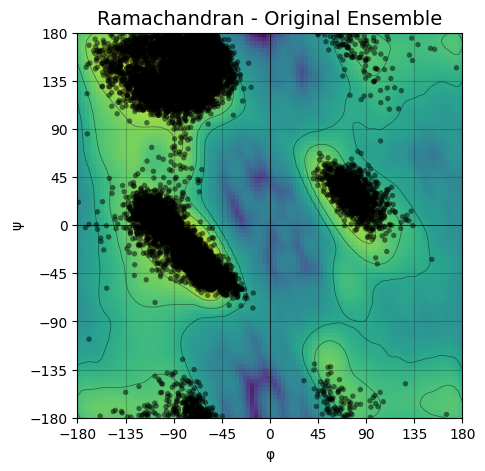

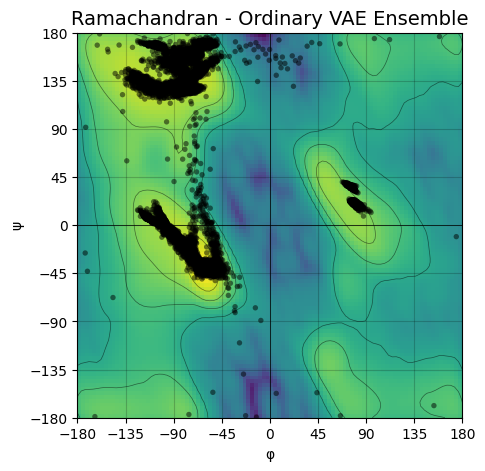

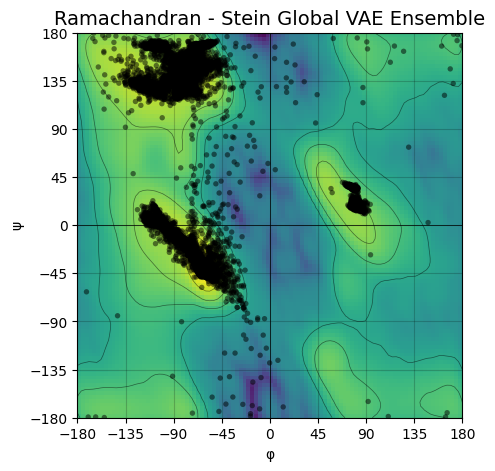

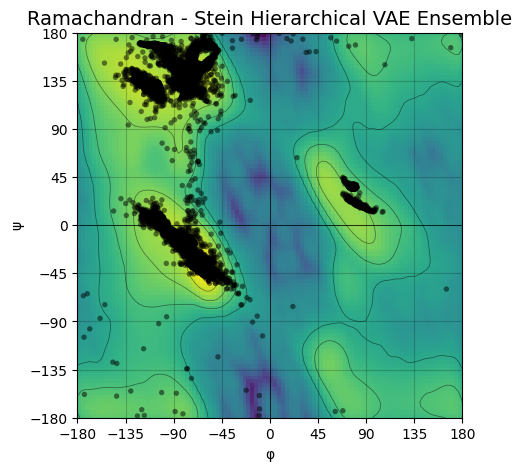

In [31]:

plot_ensemble_ramachandran("proteines/2eq8_ensemble_theseus.pdb", 
                           title="Ramachandran - Original Ensemble")

plot_ensemble_ramachandran("proteines/generated_samples_ordinary.pdb", 
                           title="Ramachandran - Ordinary VAE Ensemble")

plot_ensemble_ramachandran("proteines/generated_samples_stein_global.pdb", 
                           title="Ramachandran - Stein Global VAE Ensemble")

plot_ensemble_ramachandran("proteines/generated_samples_stein_hierarchical.pdb", 
                           title="Ramachandran - Stein Hierarchical VAE Ensemble")

In [33]:


# xtract Real Angles
real_phi, real_psi = extract_angles("proteines/2eq8_ensemble_theseus.pdb")

# Extract Generated Angles
ord_phi, ord_psi = extract_angles("proteines/generated_samples_ordinary.pdb")
glob_phi, glob_psi = extract_angles("proteines/generated_samples_stein_global.pdb")
hier_phi, hier_psi = extract_angles("proteines/generated_samples_stein_hierarchical.pdb")

# Compute JSD for each model
jsd_ord = compute_js_divergence(real_phi, real_psi, ord_phi, ord_psi)
jsd_glob = compute_js_divergence(real_phi, real_psi, glob_phi, glob_psi)
jsd_hier = compute_js_divergence(real_phi, real_psi, hier_phi, hier_psi)

jsd_stats = pd.DataFrame({
    "Model": ["Ordinary VAE", "Stein Global VAE", "Stein Hierarchical VAE"],
    "Ramachandran JSD ↓": [jsd_ord, jsd_glob, jsd_hier]
})

jsd_stats.to_latex()

'\\begin{tabular}{llr}\n\\toprule\n & Model & Ramachandran JSD ↓ \\\\\n\\midrule\n0 & Ordinary VAE & 0.155881 \\\\\n1 & Stein Global VAE & 0.130818 \\\\\n2 & Stein Hierarchical VAE & 0.124066 \\\\\n\\bottomrule\n\\end{tabular}\n'